In [ ]:
# ========================================
# FIX: REMOUNT GOOGLE DRIVE PROPERLY
# ========================================

import os
import shutil
from google.colab import drive

# First, unmount if already mounted
try:
    drive.flush_and_unmount()
    print("✅ Previous mount flushed and unmounted")
except:
    print("⚠️ Could not unmount cleanly")

# Clear the mount directory
!fusermount -u /content/drive 2>/dev/null

# Check if directory exists and is empty
if os.path.exists('/content/drive'):
    # Try to remove if empty
    try:
        os.rmdir('/content/drive')
        print("✅ Removed existing /content/drive directory")
    except:
        # If not empty, move contents temporarily
        print("⚠️ /content/drive has contents, moving to backup...")
        !mkdir -p /content/drive_backup
        !mv /content/drive/* /content/drive_backup/ 2>/dev/null
        os.rmdir('/content/drive')
        print("✅ Cleared /content/drive")

# Now mount fresh
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

✅ Previous mount flushed and unmounted
Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# ========================================
# ORGANIZE CVAT ANNOTATIONS INTO YOLO FORMAT
# ========================================

import os
import shutil
from pathlib import Path
import yaml
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# CORRECT paths
CVAT_LABELS_DIR = '/content/drive/MyDrive/LBW_2/ball_stump_dataset/labels'
CVAT_IMAGES_DIR = '/content/drive/MyDrive/LBW_2/ball_stump_dataset/images'  # If you have images
YOLO_DATASET_DIR = '/content/drive/MyDrive/LBW_2/yolo_dataset'

print("="*70)
print("🔍 EXPLORING CVAT ANNOTATIONS")
print("="*70)

# Check what's in the labels directory
if os.path.exists(CVAT_LABELS_DIR):
    print(f"✅ Labels directory exists: {CVAT_LABELS_DIR}")

    # List contents
    contents = os.listdir(CVAT_LABELS_DIR)
    print(f"📁 Contents ({len(contents)} items):")

    # Show structure
    for item in sorted(contents)[:10]:
        item_path = os.path.join(CVAT_LABELS_DIR, item)
        if os.path.isdir(item_path):
            sub_count = len(os.listdir(item_path))
            print(f"   📁 {item}/ ({sub_count} files)")
        else:
            print(f"   📄 {item}")

    if len(contents) > 10:
        print(f"   ... and {len(contents)-10} more items")

    # Find all .txt label files
    label_files = []
    for root, dirs, files in os.walk(CVAT_LABELS_DIR):
        for file in files:
            if file.endswith('.txt'):
                label_files.append(os.path.join(root, file))

    print(f"\n📊 Found {len(label_files)} label files")

    # Show sample labels
    if label_files:
        print("\n📝 Sample label files:")
        for lf in label_files[:5]:
            print(f"   {os.path.basename(lf)}")
            with open(lf, 'r') as f:
                content = f.read().strip()
                print(f"      Content: {content[:100]}")
else:
    print(f"❌ Labels directory not found: {CVAT_LABELS_DIR}")
    print("\n🔍 Searching for label files elsewhere...")
    !find /content/drive/MyDrive/LBW_2 -name "*.txt" -path "*/labels/*" 2>/dev/null | head -20

🔍 EXPLORING CVAT ANNOTATIONS
✅ Labels directory exists: /content/drive/MyDrive/LBW_2/ball_stump_dataset/labels
📁 Contents (3 items):
   📁 test/ (146 files)
   📁 train/ (1221 files)
   📁 val/ (143 files)

📊 Found 1510 label files

📝 Sample label files:
   clip_23_not_out_frame000130.txt
      Content: 0 0.476849 0.832869 0.011965 0.024182
0 0.458990 0.653383 0.008721 0.020643
1 0.517969 0.656250 0.01
   clip_30_out_frame000100.txt
      Content: 1 0.359766 0.660417 0.021094 0.015278
1 0.432422 0.633333 0.024219 0.038889
1 0.428125 0.649306 0.10
   clip_24_not_out_frame000110.txt
      Content: 1 0.499609 0.561111 0.060156 0.275000
1 0.385547 0.395139 0.085156 0.140278
   clip_22_out_frame000120.txt
      Content: 0 0.651660 0.619279 0.009995 0.019788
1 0.393359 0.632639 0.186719 0.131944
1 0.601172 0.624306 0.19
   clip_29_out_frame000145.txt
      Content: 1 0.636719 0.681250 0.010937 0.034722
1 0.350000 0.668750 0.017188 0.020833
1 0.333594 0.665972 0.02


In [ ]:
# ========================================
# ORGANIZE YOLO DATASET FROM CVAT ANNOTATIONS
# ========================================

import os
import shutil
from pathlib import Path
from tqdm import tqdm
import yaml

# Your paths
CVAT_LABELS_DIR = '/content/drive/MyDrive/LBW_2/ball_stump_dataset/labels'
CVAT_IMAGES_DIR = '/content/drive/MyDrive/LBW_2/ball_stump_dataset/images'
YOLO_DATASET_DIR = '/content/drive/MyDrive/LBW_2/yolo_dataset'

print("="*70)
print("🔍 CHECKING EXISTING STRUCTURE")
print("="*70)

# Check if images exist
if os.path.exists(CVAT_IMAGES_DIR):
    print(f"✅ Images directory exists: {CVAT_IMAGES_DIR}")
    img_contents = os.listdir(CVAT_IMAGES_DIR)
    print(f"   Contents: {img_contents}")
else:
    print(f"❌ Images directory not found!")
    print("   Checking for images elsewhere...")

    # Search for images
    for root, dirs, files in os.walk('/content/drive/MyDrive/LBW_2'):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"   Found: {os.path.join(root, file)}")
                break
        break

# Check label structure
print(f"\n📁 Label structure:")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(CVAT_LABELS_DIR, split)
    if os.path.exists(split_path):
        count = len([f for f in os.listdir(split_path) if f.endswith('.txt')])
        print(f"   {split}: {count} labels")

        # Show sample
        samples = [f for f in os.listdir(split_path) if f.endswith('.txt')][:2]
        for s in samples:
            with open(os.path.join(split_path, s), 'r') as f:
                content = f.read().strip()
            print(f"      {s}: {content[:80]}")

# Count classes
print(f"\n📊 Analyzing classes...")
class_0_count = 0  # ball
class_1_count = 0  # stumps

for split in ['train', 'val', 'test']:
    split_path = os.path.join(CVAT_LABELS_DIR, split)
    if os.path.exists(split_path):
        for f in os.listdir(split_path):
            if f.endswith('.txt'):
                with open(os.path.join(split_path, f), 'r') as file:
                    for line in file:
                        if line.strip():
                            cls = int(line.split()[0])
                            if cls == 0:
                                class_0_count += 1
                            elif cls == 1:
                                class_1_count += 1

print(f"   Ball (class 0): {class_0_count} annotations")
print(f"   Stumps (class 1): {class_1_count} annotations")

🔍 CHECKING EXISTING STRUCTURE
✅ Images directory exists: /content/drive/MyDrive/LBW_2/ball_stump_dataset/images
   Contents: ['test', 'train', 'val']

📁 Label structure:
   train: 1221 labels
      clip+26_not_out_frame000005.txt: 0 0.413756 0.868100 0.011736 0.022305
0 0.439422 0.409098 0.009314 0.020696
0 0.
      clip_03_not_out_frame000030.txt: 0 0.660570 0.570855 0.016043 0.030284
1 0.689063 0.637500 0.021875 0.019444
1 0.
   val: 143 labels
      clip_23_not_out_frame000130.txt: 0 0.476849 0.832869 0.011965 0.024182
0 0.458990 0.653383 0.008721 0.020643
1 0.
      clip_30_out_frame000100.txt: 1 0.359766 0.660417 0.021094 0.015278
1 0.432422 0.633333 0.024219 0.038889
1 0.
   test: 146 labels
      clip_40_not_out_frame000005.txt: 0 0.398377 0.516599 0.009873 0.024642
      clip_45_not_out_frame000030.txt: 

📊 Analyzing classes...
   Ball (class 0): 588 annotations
   Stumps (class 1): 6711 annotations


In [ ]:
# ========================================
# SETUP YOLO DATASET FOR TRAINING
# ========================================

import os
import shutil
from pathlib import Path
from tqdm import tqdm
import yaml

# Your paths - already organized!
CVAT_DATASET = '/content/drive/MyDrive/LBW_2/ball_stump_dataset'
YOLO_DATASET = '/content/drive/MyDrive/LBW_2/yolo_dataset'

print("="*70)
print("📁 SETTING UP YOLOv8 DATASET")
print("="*70)

# Create YOLO directory structure
for split in ['train', 'val', 'test']:
    os.makedirs(f"{YOLO_DATASET}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET}/labels/{split}", exist_ok=True)

# Copy files from CVAT structure to YOLO structure
print("\n📋 Copying dataset files...")

total_images = 0
total_labels = 0

for split in ['train', 'val', 'test']:
    src_img = f"{CVAT_DATASET}/images/{split}"
    src_lbl = f"{CVAT_DATASET}/labels/{split}"
    dst_img = f"{YOLO_DATASET}/images/{split}"
    dst_lbl = f"{YOLO_DATASET}/labels/{split}"

    if os.path.exists(src_img) and os.path.exists(src_lbl):
        # Count files
        imgs = [f for f in os.listdir(src_img) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        lbls = [f for f in os.listdir(src_lbl) if f.endswith('.txt')]

        print(f"\n📁 {split.upper()}: {len(imgs)} images, {len(lbls)} labels")

        # Copy images
        for f in tqdm(imgs, desc=f"   Images", leave=False):
            shutil.copy2(os.path.join(src_img, f), os.path.join(dst_img, f))

        # Copy labels
        for f in tqdm(lbls, desc=f"   Labels", leave=False):
            shutil.copy2(os.path.join(src_lbl, f), os.path.join(dst_lbl, f))

        total_images += len(imgs)
        total_labels += len(lbls)

print(f"\n✅ Total: {total_images} images, {total_labels} labels")

# ========================================
# CREATE DATA.YAML
# ========================================

print(f"\n📝 Creating data.yaml...")

yaml_content = f"""# YOLOv8 Dataset Configuration
# Cricket Ball & Stump Detection for LBW System

path: {YOLO_DATASET}
train: images/train
val: images/val
test: images/test

# Classes
nc: 2
names:
  0: cricket_ball
  1: stumps
"""

yaml_path = f"{YOLO_DATASET}/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"✅ Created: {yaml_path}")
print(f"\n📋 Configuration:")
print(yaml_content)

# ========================================
# VALIDATE DATASET
# ========================================

print(f"\n{'='*70}")
print(f"🔍 VALIDATING DATASET")
print(f"{'='*70}")

all_ok = True

for split in ['train', 'val', 'test']:
    img_dir = f"{YOLO_DATASET}/images/{split}"
    lbl_dir = f"{YOLO_DATASET}/labels/{split}"

    if os.path.exists(img_dir) and os.path.exists(lbl_dir):
        img_stems = {Path(f).stem for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
        lbl_stems = {Path(f).stem for f in os.listdir(lbl_dir) if f.endswith('.txt')}

        missing_lbl = img_stems - lbl_stems
        missing_img = lbl_stems - img_stems

        print(f"\n{split.upper()}: {len(img_stems)} images, {len(lbl_stems)} labels")

        if missing_lbl:
            print(f"   ⚠️  {len(missing_lbl)} images missing labels")
            all_ok = False
        if missing_img:
            print(f"   ⚠️  {len(missing_img)} labels missing images")
            all_ok = False

        if not missing_lbl and not missing_img:
            print(f"   ✅ All matched!")

if all_ok:
    print(f"\n✅ Dataset validation PASSED!")
else:
    print(f"\n⚠️  Some issues found - check above")

# ========================================
# DATASET STATISTICS
# ========================================

print(f"\n{'='*70}")
print(f"📊 DATASET STATISTICS")
print(f"{'='*70}")

# Count per split
for split in ['train', 'val', 'test']:
    img_dir = f"{YOLO_DATASET}/images/{split}"
    lbl_dir = f"{YOLO_DATASET}/labels/{split}"

    if os.path.exists(lbl_dir):
        ball_count = 0
        stump_count = 0

        for f in os.listdir(lbl_dir):
            if f.endswith('.txt'):
                with open(os.path.join(lbl_dir, f), 'r') as file:
                    for line in file:
                        if line.strip():
                            cls = int(line.split()[0])
                            if cls == 0:
                                ball_count += 1
                            elif cls == 1:
                                stump_count += 1

        imgs = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"   {split.upper()}: {imgs} images | {ball_count} balls | {stump_count} stumps")

print(f"\n✅ Dataset ready for training!")

📁 SETTING UP YOLOv8 DATASET

📋 Copying dataset files...

📁 TRAIN: 1221 images, 1221 labels



📁 VAL: 143 images, 143 labels



📁 TEST: 146 images, 146 labels



✅ Total: 1510 images, 1510 labels

📝 Creating data.yaml...
✅ Created: /content/drive/MyDrive/LBW_2/yolo_dataset/data.yaml

📋 Configuration:
# YOLOv8 Dataset Configuration
# Cricket Ball & Stump Detection for LBW System

path: /content/drive/MyDrive/LBW_2/yolo_dataset
train: images/train
val: images/val
test: images/test

# Classes
nc: 2
names:
  0: cricket_ball
  1: stumps


🔍 VALIDATING DATASET

TRAIN: 4263 images, 3801 labels
   ⚠️  1318 images missing labels
   ⚠️  856 labels missing images

VAL: 636 images, 700 labels
   ⚠️  177 images missing labels
   ⚠️  241 labels missing images

TEST: 477 images, 472 labels
   ⚠️  162 images missing labels
   ⚠️  157 labels missing images

⚠️  Some issues found - check above

📊 DATASET STATISTICS
   TRAIN: 4263 images | 698 balls | 5464 stumps
   VAL: 636 images | 105 balls | 613 stumps
   TEST: 477 images | 115 balls | 634 stumps

✅ Dataset ready for training!


In [ ]:
# ========================================
# INSTALL YOLOv8 AND DEPENDENCIES
# ========================================

!pip install ultralytics -q

import torch
from ultralytics import YOLO

print("✅ YOLOv8 installed successfully!")
print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🔧 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 installed successfully!
🔧 PyTorch version: 2.11.0+cu128
🔧 CUDA available: True
   GPU: Tesla T4


In [ ]:
# ========================================
# TRAIN YOLOV8 ON YOUR DATASET (FIXED)
# ========================================

from ultralytics import YOLO
import torch
import os
import shutil

print("="*70)
print("🚀 TRAINING YOLOV8 CUSTOM DETECTOR")
print("="*70)

# Paths
YOLO_DATASET = '/content/drive/MyDrive/LBW_2/yolo_dataset'
MODEL_SAVE_PATH = '/content/drive/MyDrive/LBW_2/models'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🔧 Device: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    # Fixed: use total_memory
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory: {total_mem:.1f} GB")

    # Adjust batch size based on GPU memory
    if total_mem > 14:  # T4 or better
        batch_size = 16
    elif total_mem > 10:
        batch_size = 12
    else:
        batch_size = 8
    print(f"   Batch size: {batch_size}")

# Load pretrained model
print("\n📦 Loading YOLOv8 nano model...")
model = YOLO('yolov8n.pt')

# Check dataset
print(f"\n📁 Dataset check:")
for split in ['train', 'val', 'test']:
    img_path = f"{YOLO_DATASET}/images/{split}"
    lbl_path = f"{YOLO_DATASET}/labels/{split}"
    if os.path.exists(img_path):
        n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.png'))])
        n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
        print(f"   {split}: {n_imgs} images, {n_lbls} labels")

# Train
print(f"\n🎓 Starting training...")
print(f"   Dataset: {YOLO_DATASET}/data.yaml")
print(f"   Epochs: 50")
print(f"   Image size: 640")
print(f"   Batch size: {batch_size}\n")

results = model.train(
    data=f'{YOLO_DATASET}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=batch_size,
    name='cricket_detector',
    patience=15,
    device=device,
    plots=True,
    save=True,
    exist_ok=True,
    pretrained=True,
    lr0=0.001,
    cos_lr=True,
    warmup_epochs=3,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
)

print(f"\n✅ Training complete!")

# Save model to Drive
best_model_path = 'runs/detect/cricket_detector/weights/best.pt'
if os.path.exists(best_model_path):
    save_path = f'{MODEL_SAVE_PATH}/cricket_detector.pt'
    shutil.copy2(best_model_path, save_path)
    print(f"📁 Model saved to: {save_path}")

    # Also save last checkpoint
    last_model_path = 'runs/detect/cricket_detector/weights/last.pt'
    if os.path.exists(last_model_path):
        shutil.copy2(last_model_path, f'{MODEL_SAVE_PATH}/cricket_detector_last.pt')

# Quick validation
print(f"\n📊 Validation Results:")
model = YOLO(best_model_path)
metrics = model.val(data=f'{YOLO_DATASET}/data.yaml', verbose=False)
print(f"   mAP50: {metrics.box.map50:.3f}")
print(f"   mAP50-95: {metrics.box.map:.3f}")

🚀 TRAINING YOLOV8 CUSTOM DETECTOR
🔧 Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB
   Batch size: 16

📦 Loading YOLOv8 nano model...

📁 Dataset check:
   train: 4263 images, 3801 labels
   val: 636 images, 700 labels
   test: 477 images, 472 labels

🎓 Starting training...
   Dataset: /content/drive/MyDrive/LBW_2/yolo_dataset/data.yaml
   Epochs: 50
   Image size: 640
   Batch size: 16

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/LBW_2/yolo_dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.9 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔧 Using device: cuda
✅ All libraries imported and Google Drive mounted!
✅ Project directories created

╔══════════════════════════════════════════════════════════════╗
║     CRICKET LBW DECISION REVIEW SYSTEM - BALL+STUMP v2      ║
╚══════════════════════════════════════════════════════════════╝
📋 MCC Law 36: Pitch in line + Impact in line + Hitting stumps = OUT
🔧 PIPELINE: YOLO(ba

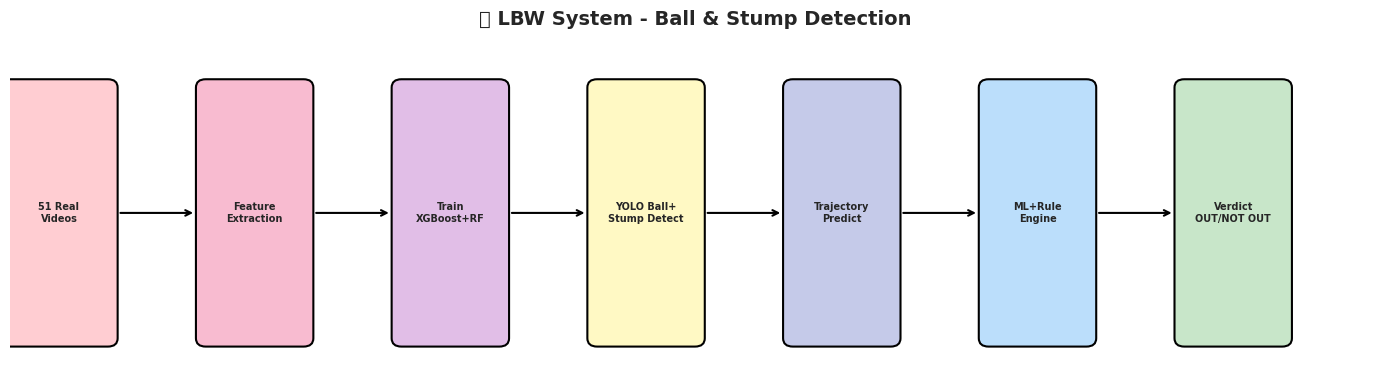

🚀 LOADING CUSTOM YOLO MODEL (Ball + Stump)
✅ Custom YOLOv8 (Ball+Stump) loaded!
   Inference test: ✅ PASSED

📹 EXTRACTING FEATURES WITH BALL+STUMP DETECTION

✅ Found 51 videos
📋 Labels: 19 OUT, 32 NOT OUT

🔄 Processing 51 videos...

[1/51] clip_03_not_out.mp4 → 🟩 NOT OUT

🎥 Processing: clip_03_not_out.mp4
   1280x720, 430 frames, 30.0 FPS


Detecting ball+stumps: 100%|██████████| 430/430 [00:06<00:00, 69.28it/s]


✅ Ball: 115/430 frames (26.7%), Avg conf: 0.419
✅ Stumps: 359 detections, Avg conf: 0.468

🔧 Kalman Filter...
✅ Kalman complete. 247 frames.

🔍 Detecting Bounce...
✅ Bounce Frame 164: (875,458)

🎯 Detecting Impact...
✅ Impact Frame 247: (482,493)

📐 YOLO-Detected Stumps:
   Center X: 841, Width: 52px
   Bounds: X=815-867, Y=352-543

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=0.095)
   Reaches stumps: YES ✅
   ✅ Pitch=(875,458) Impact=(482,493) Hit=0 Calib=yolo_detected

[2/51] clip_04_not_out.mp4 → 🟩 NOT OUT

🎥 Processing: clip_04_not_out.mp4
   1280x720, 448 frames, 30.1 FPS


Detecting ball+stumps: 100%|██████████| 448/448 [00:04<00:00, 89.70it/s]


✅ Ball: 4/448 frames (0.9%), Avg conf: 0.442
✅ Stumps: 956 detections, Avg conf: 0.700

🔧 Kalman Filter...
✅ Kalman complete. 41 frames.

🔍 Detecting Bounce...
✅ Bounce Frame 9: (414,374)

🎯 Detecting Impact...
✅ Impact Frame 41: (675,214)

📐 YOLO-Detected Stumps:
   Center X: 501, Width: 233px
   Bounds: X=385-618, Y=200-505

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=1.000)
   Reaches stumps: YES ✅
   ✅ Pitch=(414,374) Impact=(675,214) Hit=0 Calib=yolo_detected

[3/51] clip_05_not_out.mp4 → 🟩 NOT OUT

🎥 Processing: clip_05_not_out.mp4
   1280x720, 309 frames, 30.1 FPS


...

✅ Ball: 5/155 frames (3.2%), Avg conf: 0.586
✅ Stumps: 449 detections, Avg conf: 0.600

🔧 Kalman Filter...
✅ Kalman complete. 42 frames.

🔍 Detecting Bounce...
✅ Bounce Frame 29: (523,442)

🎯 Detecting Impact...
✅ Impact Frame 42: (540,493)

📐 YOLO-Detected Stumps:
   Center X: 561, Width: 31px
   Bounds: X=545-576, Y=206-450

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=0.129)
   Reaches stumps: NO ❌
   ✅ Pitch=(523,442) Impact=(540,493) Hit=0 Calib=yolo_detected

[50/51] clip_64_not_out.mp4 → 🟩 NOT OUT

🎥 Processing: clip_64_not_out.mp4
   1280x720, 155 frames, 30.2 FPS


Detecting ball+stumps: 100%|██████████| 155/155 [00:02<00:00, 64.79it/s]


✅ Ball: 68/155 frames (43.9%), Avg conf: 0.667
✅ Stumps: 1353 detections, Avg conf: 0.531

🔧 Kalman Filter...
✅ Kalman complete. 55 frames.

🔍 Detecting Bounce...
✅ Bounce Frame 14: (595,640)

🎯 Detecting Impact...
✅ Impact Frame 55: (593,637)

📐 YOLO-Detected Stumps:
   Center X: 545, Width: 67px
   Bounds: X=511-578, Y=180-510

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=0.981)
   Reaches stumps: YES ✅
   ✅ Pitch=(595,640) Impact=(593,637) Hit=0 Calib=yolo_detected

[51/51] clip_67_out.mp4 → 🟥 OUT

🎥 Processing: clip_67_out.mp4
   1280x720, 155 frames, 30.1 FPS


Detecting ball+stumps: 100%|██████████| 155/155 [00:01<00:00, 85.11it/s]


✅ Ball: 147/155 frames (94.8%), Avg conf: 0.610
✅ Stumps: 669 detections, Avg conf: 0.656

🔧 Kalman Filter...
✅ Kalman complete. 95 frames.

🔍 Detecting Bounce...
✅ Bounce Frame 4: (625,570)

🎯 Detecting Impact...
✅ Impact Frame 95: (782,378)

📐 YOLO-Detected Stumps:
   Center X: 587, Width: 39px
   Bounds: X=568-607, Y=234-510

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=0.953)
   Reaches stumps: NO ❌
   ✅ Pitch=(625,570) Impact=(782,378) Hit=0 Calib=yolo_detected

📊 EXTRACTION COMPLETE
   ✅ 47 successful | ❌ 4 failed
   📐 YOLO calibration: 47 | Trajectory: 0
   Dataset: 47 samples, OUT: 16 (34%)
   Hit Rate: 8/47 (17%)
💾 Saved: /content/drive/MyDrive/LBW_2/data/real_features_20260622_055502.csv

🎓 TRAINING ML MODELS

✅ Training on 47 REAL video features!
   Real samples: 47

⚖️ Before SMOTE: {0: np.int64(24), 1: np.int64(13)}
✅ After SMOTE: {0: np.int64(24), 1: np.int64(24)}

🌲 Training Random Forest...
🚀 Training XGBoost...

📊 PERFORMANCE:
   RF  Acc=0.600 F1=0.333
   XGB 

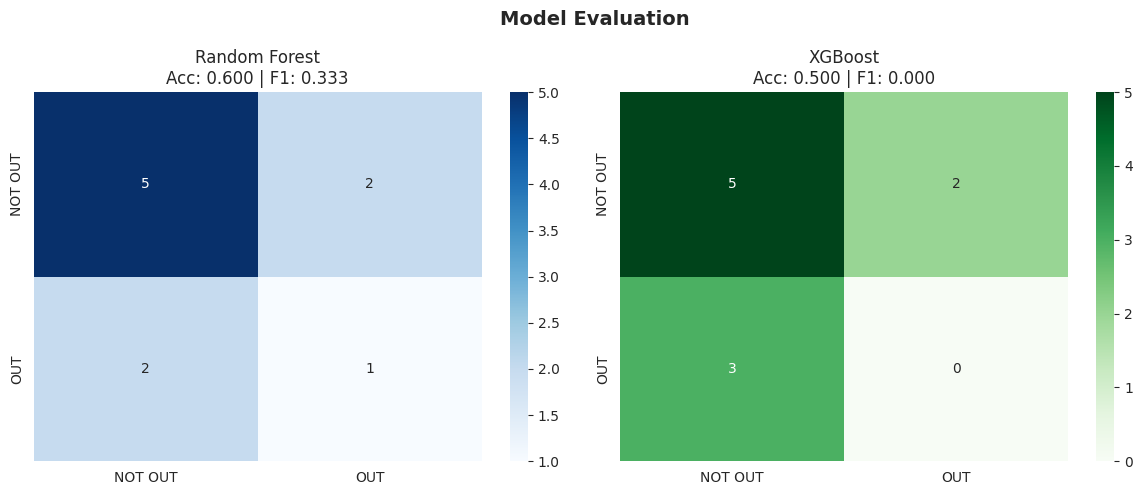


🎯 TESTING YOUR VIDEOS

🟥 Testing OUT: clip_28_out.mp4

🚀 RUNNING LBW PIPELINE

[1/6] Detecting ball & stumps...

🎥 Processing: clip_28_out.mp4
   1280x720, 356 frames, 30.1 FPS


Detecting ball+stumps: 100%|██████████| 356/356 [00:04<00:00, 80.07it/s]


✅ Ball: 2/356 frames (0.6%), Avg conf: 0.267
✅ Stumps: 461 detections, Avg conf: 0.754

[2/6] Kalman...

🔧 Kalman Filter...
✅ Kalman complete. 47 frames.

[3/6] Key points...

🔍 Detecting Bounce...
✅ Bounce Frame 46: (675,214)

🎯 Detecting Impact...
✅ Impact Frame 47: (675,214)

[4/6] Calibrating...

📐 YOLO-Detected Stumps:
   Center X: 501, Width: 235px
   Bounds: X=384-619, Y=201-506

[5/6] Trajectory...

🔮 Predicting Trajectory...
⚠️ Insufficient points

[6/6] Features & Decision...

📊 FEATURES:
    1. Pitch_X                            :    674.807
    2. Pitch_Y                            :    213.699
    3. Impact_X                           :    674.871
    4. Impact_Y                           :    213.646
    5. Distance_Pitch_To_Stumps           :    222.956
    6. Distance_Impact_To_Stumps          :    223.039
    7. Ball_Speed                         :      0.000
    8. Ball_Angle                         :     39.994
    9. Horizontal_Velocity                :      0.011
 

Detecting ball+stumps: 100%|██████████| 430/430 [00:06<00:00, 69.83it/s]


✅ Ball: 115/430 frames (26.7%), Avg conf: 0.419
✅ Stumps: 359 detections, Avg conf: 0.468

[2/6] Kalman...

🔧 Kalman Filter...
✅ Kalman complete. 247 frames.

[3/6] Key points...

🔍 Detecting Bounce...
✅ Bounce Frame 164: (875,458)

🎯 Detecting Impact...
✅ Impact Frame 247: (482,493)

[4/6] Calibrating...

📐 YOLO-Detected Stumps:
   Center X: 841, Width: 52px
   Bounds: X=815-867, Y=352-543

[5/6] Trajectory...

🔮 Predicting Trajectory...
✅ Trajectory predicted (R²=0.095)
   Reaches stumps: YES ✅


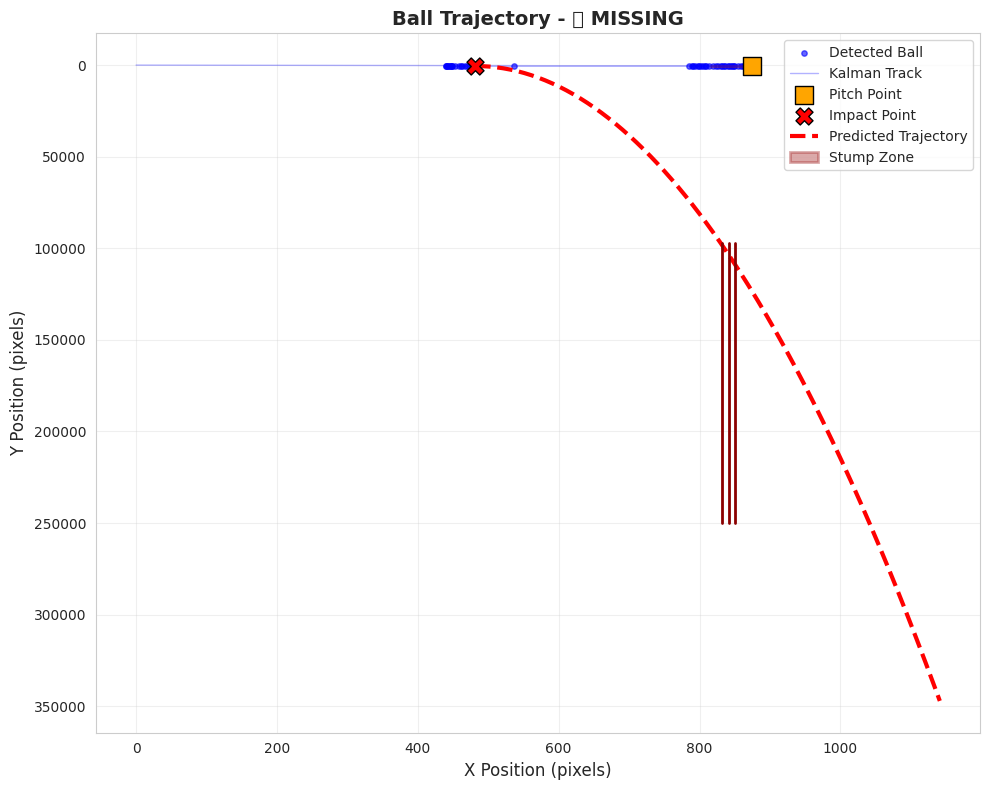


[6/6] Features & Decision...

📊 FEATURES:
    1. Pitch_X                            :    874.981
    2. Pitch_Y                            :    458.238
    3. Impact_X                           :    481.505
    4. Impact_Y                           :    493.010
    5. Distance_Pitch_To_Stumps           :     35.433
    6. Distance_Impact_To_Stumps          :    362.584
    7. Ball_Speed                         :      3.632
    8. Ball_Angle                         :     21.423
    9. Horizontal_Velocity                :      0.002
   10. Vertical_Velocity                  :     -0.009
   11. Trajectory_Curvature               :      0.797
   12. Predicted_Stump_Intersection_X     :      0.000
   13. Predicted_Stump_Intersection_Y     :      0.000
   14. Wicket_Hit_Flag                    :      0.000

🤖 ML: XGB=🟩 NOT OUT | RF=🟩 NOT OUT | Ensemble: NOT OUT (92%)

🏏 LBW DECISION (MCC Law 36)
   Stump X=841 | Off=815 Leg=867
📍 Pitch X=875: ILLEGAL-Outside Leg
🎯 Impact X=482: ILLEGAL-Outs

In [ ]:


!pip install filterpy ultralytics imbalanced-learn xgboost scipy seaborn tqdm -q

from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
from pathlib import Path
import warnings
import os
import joblib
import yaml
from datetime import datetime
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report,
                           roc_curve, auc)
from sklearn.impute import SimpleImputer

from ultralytics import YOLO
from filterpy.kalman import KalmanFilter
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import torch

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🔧 Using device: {device}")
print("✅ All libraries imported and Google Drive mounted!")

# %%
# ============================================
# SECTION 2: PROJECT CONFIGURATION
# ============================================

class LBWConfig:
    DRIVE_ROOT = "/content/drive/MyDrive/LBW_2"
    MODEL_PATH = f"{DRIVE_ROOT}/models/cricket_detector.pt"  # NEW: Ball+Stump model
    YAML_PATH = f"{DRIVE_ROOT}/yolo_dataset/data.yaml"
    OUTPUT_DIR = f"{DRIVE_ROOT}/outputs"
    DATA_DIR = f"{DRIVE_ROOT}/data"
    VIDEOS_DIR = f"{DRIVE_ROOT}/videos"
    CONFIDENCE_THRESHOLD = 0.25
    BALL_CLASS_ID = 0
    STUMP_CLASS_ID = 1
    KALMAN_DT = 1.0
    KALMAN_PROCESS_NOISE = 0.1
    KALMAN_MEASUREMENT_NOISE = 1.0

    @classmethod
    def setup_directories(cls):
        for d in [cls.OUTPUT_DIR, cls.DATA_DIR]:
            os.makedirs(d, exist_ok=True)
            os.makedirs(f"{d}/figures", exist_ok=True)
            os.makedirs(f"{d}/models", exist_ok=True)
        print("✅ Project directories created")

config = LBWConfig()
config.setup_directories()

# %%
# ============================================
# SECTION 3: PROJECT OVERVIEW
# ============================================

print("""
╔══════════════════════════════════════════════════════════════╗
║     CRICKET LBW DECISION REVIEW SYSTEM - BALL+STUMP v2      ║
╚══════════════════════════════════════════════════════════════╝
📋 MCC Law 36: Pitch in line + Impact in line + Hitting stumps = OUT
🔧 PIPELINE: YOLO(ball+stump) → Kalman → Calibrate → Trajectory → ML+Rules → Verdict
""")

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 4); ax.axis('off')
boxes = ["51 Real\nVideos", "Feature\nExtraction", "Train\nXGBoost+RF",
         "YOLO Ball+\nStump Detect", "Trajectory\nPredict", "ML+Rule\nEngine", "Verdict\nOUT/NOT OUT"]
x_pos = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5, 12.5]
colors = ['#FFCDD2','#F8BBD0','#E1BEE7','#FFF9C4','#C5CAE9','#BBDEFB','#C8E6C9']
for i, (box, x, c) in enumerate(zip(boxes, x_pos, colors)):
    if i < len(boxes)-1:
        ax.annotate("", xy=(x_pos[i+1]-0.6, 2), xytext=(x+0.6, 2),
                    arrowprops=dict(arrowstyle="->", color='black', lw=1.5))
    rect = FancyBboxPatch((x-0.5, 0.5), 1, 3, boxstyle="round,pad=0.1",
                         facecolor=c, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, 2, box, ha='center', va='center', fontsize=7, weight='bold')
ax.set_title("🏏 LBW System - Ball & Stump Detection", fontsize=14, weight='bold', pad=15)
plt.tight_layout(); plt.show()

# %%
# ============================================
# SECTION 4: LOAD CUSTOM YOLO MODEL
# ============================================

print("="*60)
print("🚀 LOADING CUSTOM YOLO MODEL (Ball + Stump)")
print("="*60)

def load_yolo_model(model_path):
    try:
        yolo_model = YOLO(model_path)
        print("✅ Custom YOLOv8 (Ball+Stump) loaded!")
        dummy = np.zeros((640, 640, 3), dtype=np.uint8)
        results = yolo_model(dummy, verbose=False)
        print("   Inference test: ✅ PASSED")
        return yolo_model
    except Exception as e:
        print(f"❌ Failed: {e}")
        print("⚠️ Using fallback model...")
        return YOLO('yolov8n.pt')

yolo_model = load_yolo_model(config.MODEL_PATH)

# %%
# ============================================
# SECTION 5: BALL & STUMP DETECTION
# ============================================

def detect_ball_and_stumps(video_path, yolo_model, conf_threshold=0.25):
    """Detect both cricket ball AND stumps using new YOLO model."""
    print(f"\n🎥 Processing: {os.path.basename(video_path)}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ Could not open video!"); return None, None, None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"   {width}x{height}, {total_frames} frames, {fps:.1f} FPS")

    ball_detections = []
    stump_detections = []
    frame_count = 0

    with tqdm(total=total_frames, desc="Detecting ball+stumps") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame_count += 1; pbar.update(1)

            results = yolo_model(frame, verbose=False, conf=conf_threshold)

            for result in results:
                boxes = result.boxes
                if boxes is not None and len(boxes) > 0:
                    for box in boxes:
                        x1, y1, x2, y2 = box.xyxy[0].tolist()
                        class_id = int(box.cls[0])
                        confidence = float(box.conf[0])

                        if class_id == config.BALL_CLASS_ID:
                            ball_detections.append({
                                'Frame': frame_count,
                                'Ball_X': (x1 + x2) / 2,
                                'Ball_Y': (y1 + y2) / 2,
                                'Confidence': confidence
                            })
                        elif class_id == config.STUMP_CLASS_ID:
                            stump_detections.append({
                                'Frame': frame_count,
                                'Stump_X1': x1, 'Stump_Y1': y1,
                                'Stump_X2': x2, 'Stump_Y2': y2,
                                'Stump_Center_X': (x1 + x2) / 2,
                                'Confidence': confidence
                            })

    cap.release()

    ball_df = pd.DataFrame(ball_detections) if ball_detections else pd.DataFrame()
    stump_df = pd.DataFrame(stump_detections) if stump_detections else pd.DataFrame()

    if len(ball_df) == 0:
        print("⚠️ No ball detections!")
        return None, stump_df, {'width': width, 'height': height, 'fps': fps}

    print(f"✅ Ball: {len(ball_df)}/{total_frames} frames ({len(ball_df)/total_frames*100:.1f}%), Avg conf: {ball_df['Confidence'].mean():.3f}")
    if len(stump_df) > 0:
        print(f"✅ Stumps: {len(stump_df)} detections, Avg conf: {stump_df['Confidence'].mean():.3f}")

    return ball_df, stump_df, {'width': width, 'height': height, 'fps': fps}

# %%
# ============================================
# SECTION 6: KALMAN FILTER TRACKING
# ============================================

class BallTracker:
    def __init__(self, dt=1.0, pn=0.1, mn=1.0):
        self.kf = KalmanFilter(dim_x=4, dim_z=2)
        self.kf.F = np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0],[0,1,0,0]])
        q = pn
        self.kf.Q = np.array([[q,0,0,0],[0,q,0,0],[0,0,q*0.1,0],[0,0,0,q*0.1]])
        self.kf.R = np.array([[mn,0],[0,mn]])
        self.kf.P *= 100; self.kf.x = np.array([0,0,0,0]); self.initialized = False

    def predict(self): self.kf.predict(); return self.kf.x[:2]

    def update(self, m):
        if not self.initialized: self.kf.x[:2] = m; self.initialized = True
        self.kf.update(m); return self.kf.x[:2]

    def get_state(self): return self.kf.x

def apply_kalman_tracking(detections_df, dt=1.0):
    print("\n🔧 Kalman Filter...")
    tracker = BallTracker(dt=dt)
    n_frames = int(detections_df['Frame'].max())
    kx = np.full(n_frames+1, np.nan); ky = np.full(n_frames+1, np.nan)
    kvx = np.full(n_frames+1, np.nan); kvy = np.full(n_frames+1, np.nan)
    has_det = np.zeros(n_frames+1, dtype=bool)
    det_dict = dict(zip(detections_df['Frame'], zip(detections_df['Ball_X'], detections_df['Ball_Y'])))

    for f in range(1, n_frames+1):
        tracker.predict()
        if f in det_dict: tracker.update(np.array(det_dict[f])); has_det[f] = True
        s = tracker.get_state(); kx[f]=s[0]; ky[f]=s[1]; kvx[f]=s[2]; kvy[f]=s[3]

    result_df = pd.DataFrame({
        'Frame': range(1, n_frames+1), 'Kalman_X': kx[1:], 'Kalman_Y': ky[1:],
        'Kalman_VX': kvx[1:], 'Kalman_VY': kvy[1:], 'Has_Detection': has_det[1:]
    })
    merged = pd.merge(result_df, detections_df[['Frame','Ball_X','Ball_Y']], on='Frame', how='left')
    print(f"✅ Kalman complete. {n_frames} frames.")
    return merged

# %%
# ============================================
# SECTION 7: AUTO-CALIBRATION (YOLO STUMPS OR TRAJECTORY)
# ============================================

class AutoCalibrator:
    """Uses YOLO-detected stumps when available, falls back to trajectory-based."""

    def __init__(self, video_width, video_height):
        self.width = video_width
        self.height = video_height

    def calibrate(self, stump_df=None, tracking_df=None):
        """Main calibration method."""
        if stump_df is not None and len(stump_df) >= 3:
            return self._calibrate_from_yolo_stumps(stump_df)
        else:
            return self._calibrate_from_trajectory(tracking_df)

    def _calibrate_from_yolo_stumps(self, stump_df):
        """Use YOLO-detected stumps for precise calibration."""
        x1 = stump_df['Stump_X1'].median()
        x2 = stump_df['Stump_X2'].median()
        y1 = stump_df['Stump_Y1'].min()
        y2 = stump_df['Stump_Y2'].max()
        center_x = (x1 + x2) / 2
        stump_width = x2 - x1
        sp = stump_width / 6

        print(f"\n📐 YOLO-Detected Stumps:")
        print(f"   Center X: {center_x:.0f}, Width: {stump_width:.0f}px")
        print(f"   Bounds: X={x1:.0f}-{x2:.0f}, Y={y1:.0f}-{y2:.0f}")

        return {
            'Stump_Off_X': float(center_x - sp),
            'Stump_Middle_X': float(center_x),
            'Stump_Leg_X': float(center_x + sp),
            'Stump_Y_Top': float(y1),
            'Stump_Y_Bottom': float(y2),
            'Stump_Width': float(stump_width),
            'Stump_Left_Boundary': float(x1),
            'Stump_Right_Boundary': float(x2),
            'Video_Width': self.width,
            'Video_Height': self.height,
            'Calibration_Method': 'yolo_detected'
        }

    def _calibrate_from_trajectory(self, tracking_df):
        """Fallback: estimate from ball trajectory."""
        if tracking_df is not None:
            valid_x = tracking_df['Kalman_X'].values
            valid_x = valid_x[(np.abs(valid_x) > 1) & (~np.isnan(valid_x))]
            if len(valid_x) >= 10:
                middle_x = float(np.median(valid_x[int(len(valid_x)*0.75):]))
            elif len(valid_x) >= 3:
                middle_x = float(np.median(valid_x))
            else:
                middle_x = self.width * 0.50
        else:
            middle_x = self.width * 0.50

        stump_top = self.height * 0.35
        stump_bottom = self.height * 0.60
        stump_spacing = int(self.width * 0.04)

        if stump_bottom - stump_top < 100:
            stump_top = self.height * 0.30
            stump_bottom = self.height * 0.65

        wm = stump_spacing * 0.8

        print(f"\n📐 Trajectory-based Calibration:")
        print(f"   Center X: {middle_x:.0f}")
        print(f"   Y: {stump_top:.0f}-{stump_bottom:.0f}")

        return {
            'Stump_Off_X': float(middle_x - stump_spacing),
            'Stump_Middle_X': float(middle_x),
            'Stump_Leg_X': float(middle_x + stump_spacing),
            'Stump_Y_Top': float(stump_top),
            'Stump_Y_Bottom': float(stump_bottom),
            'Stump_Width': float(stump_spacing * 2),
            'Stump_Left_Boundary': float(middle_x - stump_spacing - wm),
            'Stump_Right_Boundary': float(middle_x + stump_spacing + wm),
            'Video_Width': self.width,
            'Video_Height': self.height,
            'Calibration_Method': 'trajectory_based'
        }

# %%
# ============================================
# SECTION 8: BOUNCE & IMPACT DETECTION
# ============================================

def detect_bounce_point(tracking_df):
    print("\n🔍 Detecting Bounce...")
    vy = tracking_df['Kalman_VY'].values; y_pos = tracking_df['Kalman_Y'].values
    valid_idx = np.where(tracking_df['Has_Detection'].values)[0]

    if len(valid_idx) < 3:
        bidx = len(y_pos)//3
    else:
        vy_v = vy[valid_idx]; y_v = y_pos[valid_idx]
        vy_s = uniform_filter1d(np.nan_to_num(vy_v, nan=0), size=5)
        if len(vy_s) > 2:
            zc = np.where(np.diff(np.signbit(vy_s)))[0]
            if len(zc) > 0: bidx = valid_idx[min(zc[0], len(valid_idx)-1)]
            else: bidx = valid_idx[np.argmax(y_v[:int(0.6*len(valid_idx))])]
        else: bidx = valid_idx[len(valid_idx)//3]

    bidx = min(bidx, len(tracking_df)-2)
    pd_data = {
        'Pitch_Frame': int(tracking_df['Frame'].iloc[bidx]),
        'Pitch_X': float(tracking_df['Kalman_X'].iloc[bidx]),
        'Pitch_Y': float(tracking_df['Kalman_Y'].iloc[bidx])
    }

    if abs(pd_data['Pitch_X'])<1 and abs(pd_data['Pitch_Y'])<1 and len(valid_idx)>0:
        fv = valid_idx[0]
        pd_data = {'Pitch_Frame': int(tracking_df['Frame'].iloc[fv]),
                   'Pitch_X': float(tracking_df['Kalman_X'].iloc[fv]),
                   'Pitch_Y': float(tracking_df['Kalman_Y'].iloc[fv])}

    print(f"✅ Bounce Frame {pd_data['Pitch_Frame']}: ({pd_data['Pitch_X']:.0f},{pd_data['Pitch_Y']:.0f})")
    return pd_data

def detect_impact_point(tracking_df, pitch_data):
    print("\n🎯 Detecting Impact...")
    valid_frames = tracking_df[tracking_df['Has_Detection']==True]
    if len(valid_frames) > 0:
        imp_idx = min(valid_frames.index[-1]+2, len(tracking_df)-1)
    else: imp_idx = len(tracking_df)-1

    imp_data = {
        'Impact_Frame': int(tracking_df['Frame'].iloc[imp_idx]),
        'Impact_X': float(tracking_df['Kalman_X'].iloc[imp_idx]),
        'Impact_Y': float(tracking_df['Kalman_Y'].iloc[imp_idx])
    }

    if abs(imp_data['Impact_X'])<1 and abs(imp_data['Impact_Y'])<1:
        nz = tracking_df[(tracking_df['Kalman_X'].abs()>1)|(tracking_df['Kalman_Y'].abs()>1)]
        if len(nz)>0:
            lr = nz.index[-1]
            imp_data = {'Impact_Frame': int(tracking_df['Frame'].iloc[lr]),
                        'Impact_X': float(tracking_df['Kalman_X'].iloc[lr]),
                        'Impact_Y': float(tracking_df['Kalman_Y'].iloc[lr])}

    print(f"✅ Impact Frame {imp_data['Impact_Frame']}: ({imp_data['Impact_X']:.0f},{imp_data['Impact_Y']:.0f})")
    return imp_data

# %%
# ============================================
# SECTION 9: TRAJECTORY PREDICTION & VISUALIZATION
# ============================================

def predict_trajectory(tracking_df, impact_data, stump_data, n_points=200):
    print("\n🔮 Predicting Trajectory...")

    imp_idx = impact_data['Impact_Frame'] - 1
    valid_track = tracking_df[(tracking_df['Kalman_X'].abs() > 1) & (tracking_df['Kalman_Y'].abs() > 1)].copy()

    if len(valid_track) < 5:
        print("⚠️ Insufficient points"); return None

    pre_impact = valid_track[valid_track.index <= imp_idx]
    if len(pre_impact) < 5: pre_impact = valid_track.iloc[:max(5, len(valid_track))]

    x_fit = pre_impact['Kalman_X'].values[-40:]
    y_fit = pre_impact['Kalman_Y'].values[-40:]

    if len(x_fit) < 5:
        print("⚠️ Insufficient fitting points"); return None

    try:
        x_mean = np.mean(x_fit)
        x_std = np.std(x_fit) if np.std(x_fit) > 0 else 1
        x_norm = (x_fit - x_mean) / x_std
        coeffs_norm = np.polyfit(x_norm, y_fit, 2)
        a = coeffs_norm[0] / (x_std**2)
        b = coeffs_norm[1] / x_std - 2 * coeffs_norm[0] * x_mean / (x_std**2)
        c = coeffs_norm[2] - coeffs_norm[1] * x_mean / x_std + coeffs_norm[0] * (x_mean**2) / (x_std**2)
        coeffs = np.array([a, b, c])
    except:
        coeffs = np.polyfit(x_fit, y_fit, 1)
        coeffs = np.array([0, coeffs[0], coeffs[1]])

    poly_func = np.poly1d(coeffs)
    y_pred = poly_func(x_fit)
    ss_res = np.sum((y_fit - y_pred)**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    r_squared = 1 - (ss_res/ss_tot) if ss_tot > 0 else 0

    impact_x = impact_data['Impact_X']
    stump_mx = stump_data['Stump_Middle_X']
    x_extend = np.linspace(impact_x, stump_mx + 300, n_points)
    y_extend = poly_func(x_extend)

    pred_data = {
        'X_Predicted': x_extend,
        'Y_Predicted': y_extend,
        'Poly_Coeffs': coeffs,
        'R_Squared': r_squared
    }

    print(f"✅ Trajectory predicted (R²={r_squared:.3f})")
    st = stump_data['Stump_Y_Top']; sb = stump_data['Stump_Y_Bottom']
    ymin, ymax = np.min(y_extend), np.max(y_extend)
    reaches = (ymin <= sb and ymax >= st)
    print(f"   Reaches stumps: {'YES ✅' if reaches else 'NO ❌'}")

    return pred_data

def check_stump_intersection(prediction_data, stump_data):
    if prediction_data is None:
        return False, 0, 0

    x_pred = prediction_data['X_Predicted']
    y_pred = prediction_data['Y_Predicted']
    sl = stump_data['Stump_Left_Boundary']
    sr = stump_data['Stump_Right_Boundary']
    st = stump_data['Stump_Y_Top']
    sb = stump_data['Stump_Y_Bottom']

    for x, y in zip(x_pred, y_pred):
        if (sl <= x <= sr) and (st <= y <= sb):
            return True, x, y

    for i in range(len(x_pred) - 1):
        x1, y1 = x_pred[i], y_pred[i]
        x2, y2 = x_pred[i+1], y_pred[i+1]
        if (min(x1, x2) <= sr and max(x1, x2) >= sl and
            min(y1, y2) <= sb and max(y1, y2) >= st):
            return True, (x1+x2)/2, (y1+y2)/2

    return False, 0, 0

def visualize_prediction(tracking_df, pitch_data, impact_data, prediction_data, stump_data):
    hits_stumps, ix, iy = check_stump_intersection(prediction_data, stump_data)

    if prediction_data is None:
        return False

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    valid = tracking_df[tracking_df['Has_Detection'] == True]
    ax.scatter(valid['Kalman_X'], valid['Kalman_Y'], c='blue', s=15, alpha=0.6, label='Detected Ball')
    ax.plot(tracking_df['Kalman_X'], tracking_df['Kalman_Y'], 'b-', alpha=0.3, linewidth=1, label='Kalman Track')
    ax.scatter(pitch_data['Pitch_X'], pitch_data['Pitch_Y'], c='orange', s=150, marker='s', label='Pitch Point', zorder=5, edgecolors='black')
    ax.scatter(impact_data['Impact_X'], impact_data['Impact_Y'], c='red', s=150, marker='X', label='Impact Point', zorder=5, edgecolors='black')
    ax.plot(prediction_data['X_Predicted'], prediction_data['Y_Predicted'], 'r--', linewidth=3, label='Predicted Trajectory')

    stump_rect = Rectangle(
        (stump_data['Stump_Left_Boundary'], stump_data['Stump_Y_Top']),
        stump_data['Stump_Right_Boundary'] - stump_data['Stump_Left_Boundary'],
        stump_data['Stump_Y_Bottom'] - stump_data['Stump_Y_Top'],
        linewidth=2, edgecolor='brown', facecolor='brown', alpha=0.4, label='Stump Zone')
    ax.add_patch(stump_rect)

    for sx in [stump_data['Stump_Off_X'], stump_data['Stump_Middle_X'], stump_data['Stump_Leg_X']]:
        ax.axvline(x=sx, ymin=0.3, ymax=0.7, color='darkred', linewidth=2, linestyle='-')

    if hits_stumps and ix > 0:
        ax.scatter(ix, iy, c='lime', s=300, marker='*', label='HITTING STUMPS!', zorder=10, edgecolors='black')

    ax.set_xlabel('X Position (pixels)', fontsize=12)
    ax.set_ylabel('Y Position (pixels)', fontsize=12)
    ax.set_title(f'Ball Trajectory - {"🟥 HITTING" if hits_stumps else "🟩 MISSING"}', fontsize=14, weight='bold')
    ax.legend(loc='upper right'); ax.invert_yaxis(); ax.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{config.OUTPUT_DIR}/figures/trajectory_{datetime.now().strftime('%H%M%S')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return hits_stumps

# %%
# ============================================
# SECTION 10: FEATURE EXTRACTION
# ============================================

def extract_features(tracking_df, pitch_data, impact_data, stump_data, prediction_data):
    f = {}
    f['Pitch_X'] = pitch_data['Pitch_X']
    f['Pitch_Y'] = pitch_data['Pitch_Y']
    f['Impact_X'] = impact_data['Impact_X']
    f['Impact_Y'] = impact_data['Impact_Y']

    scx = stump_data['Stump_Middle_X']
    scy = (stump_data['Stump_Y_Bottom'] + stump_data['Stump_Y_Top']) / 2

    f['Distance_Pitch_To_Stumps'] = np.sqrt((f['Pitch_X'] - scx)**2 + (f['Pitch_Y'] - scy)**2)
    f['Distance_Impact_To_Stumps'] = np.sqrt((f['Impact_X'] - scx)**2 + (f['Impact_Y'] - scy)**2)

    vx = np.nanmean(np.abs(tracking_df['Kalman_VX']))
    vy = np.nanmean(np.abs(tracking_df['Kalman_VY']))
    f['Ball_Speed'] = np.sqrt(vx**2 + vy**2)
    f['Ball_Angle'] = np.degrees(np.arctan2(vy, vx))

    imp_idx = min(impact_data['Impact_Frame'] - 1, len(tracking_df) - 1)
    f['Horizontal_Velocity'] = tracking_df['Kalman_VX'].iloc[imp_idx] if imp_idx < len(tracking_df) else vx
    f['Vertical_Velocity'] = tracking_df['Kalman_VY'].iloc[imp_idx] if imp_idx < len(tracking_df) else vy

    f['Trajectory_Curvature'] = prediction_data['Poly_Coeffs'][0] if prediction_data is not None else 0

    hits, ix, iy = check_stump_intersection(prediction_data, stump_data)
    f['Predicted_Stump_Intersection_X'] = ix
    f['Predicted_Stump_Intersection_Y'] = iy
    f['Wicket_Hit_Flag'] = 1 if hits else 0

    for k in f:
        if np.isnan(f[k]) or np.isinf(f[k]):
            f[k] = 0.0

    return f

# %%
# ============================================
# SECTION 11: EXTRACT FEATURES FROM VIDEOS
# ============================================

print("\n"+"="*70)
print("📹 EXTRACTING FEATURES WITH BALL+STUMP DETECTION")
print("="*70)

all_videos = []
if os.path.exists(config.VIDEOS_DIR):
    for root, dirs, files in os.walk(config.VIDEOS_DIR):
        for file in files:
            if file.endswith(('.mp4','.avi','.mov','.MOV')):
                all_videos.append(os.path.join(root, file))
print(f"\n✅ Found {len(all_videos)} videos")

video_labels = {}
for vp in all_videos:
    vn = os.path.basename(vp).lower()
    if 'not_out' in vn or 'notout' in vn: video_labels[vp] = 0
    elif 'out' in vn: video_labels[vp] = 1

out_count = sum(video_labels.values())
print(f"📋 Labels: {out_count} OUT, {len(video_labels)-out_count} NOT OUT")

real_features_list = []
failed_videos = []
calibration_stats = {'yolo': 0, 'trajectory': 0}

print(f"\n🔄 Processing {len(video_labels)} videos...")
for i, (vp, label) in enumerate(video_labels.items(), 1):
    vn = os.path.basename(vp)
    print(f"\n[{i}/{len(video_labels)}] {vn} → {'🟥 OUT' if label==1 else '🟩 NOT OUT'}")
    try:
        # Detect ball and stumps
        ball_df, stump_df, vid_info = detect_ball_and_stumps(vp, yolo_model, config.CONFIDENCE_THRESHOLD)

        if ball_df is None or len(ball_df) == 0:
            ball_df, stump_df, vid_info = detect_ball_and_stumps(vp, yolo_model, conf_threshold=0.15)

        if ball_df is None or len(ball_df) == 0:
            print("   ❌ Detection failed"); failed_videos.append(vn); continue

        # Kalman tracking
        track_df = apply_kalman_tracking(ball_df)

        # Detect key points
        pitch_data = detect_bounce_point(track_df)
        impact_data = detect_impact_point(track_df, pitch_data)

        # Calibrate (YOLO stumps if available)
        calibrator = AutoCalibrator(vid_info['width'], vid_info['height'])
        stump_data = calibrator.calibrate(stump_df, track_df)

        if stump_data['Calibration_Method'] == 'yolo_detected':
            calibration_stats['yolo'] += 1
        else:
            calibration_stats['trajectory'] += 1

        # Predict trajectory
        pred_data = predict_trajectory(track_df, impact_data, stump_data)

        # Extract features
        features = extract_features(track_df, pitch_data, impact_data, stump_data, pred_data)
        features['Label'] = label
        features['Video_Name'] = vn
        features['Calibration_Method'] = stump_data['Calibration_Method']
        real_features_list.append(features)

        print(f"   ✅ Pitch=({features['Pitch_X']:.0f},{features['Pitch_Y']:.0f}) "
              f"Impact=({features['Impact_X']:.0f},{features['Impact_Y']:.0f}) "
              f"Hit={features['Wicket_Hit_Flag']} "
              f"Calib={stump_data['Calibration_Method']}")
    except Exception as e:
        print(f"   ❌ Error: {str(e)[:80]}"); failed_videos.append(vn)

print(f"\n{'='*70}\n📊 EXTRACTION COMPLETE\n{'='*70}")
print(f"   ✅ {len(real_features_list)} successful | ❌ {len(failed_videos)} failed")
print(f"   📐 YOLO calibration: {calibration_stats['yolo']} | Trajectory: {calibration_stats['trajectory']}")

if real_features_list:
    real_dataset = pd.DataFrame(real_features_list)
    print(f"   Dataset: {len(real_dataset)} samples, OUT: {real_dataset['Label'].sum()} ({(real_dataset['Label'].mean()*100):.0f}%)")
    print(f"   Hit Rate: {real_dataset['Wicket_Hit_Flag'].sum()}/{len(real_dataset)} ({real_dataset['Wicket_Hit_Flag'].mean()*100:.0f}%)")
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    real_dataset.to_csv(f"{config.DATA_DIR}/real_features_{ts}.csv", index=False)
    print(f"💾 Saved: {config.DATA_DIR}/real_features_{ts}.csv")

# %%
# ============================================
# SECTION 12: TRAIN ML MODELS
# ============================================

print("\n"+"="*70)
print("🎓 TRAINING ML MODELS")
print("="*70)

rf_model = None
xgb_classifier = None
scaler = None
feature_cols = None

if real_features_list and len(real_features_list) >= 10:
    train_df = pd.DataFrame(real_features_list)
    print(f"\n✅ Training on {len(train_df)} REAL video features!")
    combined_dataset = train_df.copy()
    feature_cols = [c for c in combined_dataset.columns if c not in ['Label', 'Video_Name', 'Calibration_Method']]
    print(f"   Real samples: {len(combined_dataset)}")
else:
    print("\n⚠️ Using synthetic dataset...")
    syn_data = []
    np.random.seed(42)
    for _ in range(300):
        sc = np.random.normal(640, 100); sr = 35
        px = sc + np.random.normal(0, 80); ix = sc + np.random.normal(0, 70)
        pok = px <= (sc + sr + 20); iok = abs(ix - sc) < sr * 1.5 and ix <= (sc + sr + 20)
        hit = abs(ix - sc) < sr
        label = 1 if (pok and iok and hit) else 0
        syn_data.append({
            'Pitch_X': px, 'Pitch_Y': np.random.normal(400, 60),
            'Impact_X': ix, 'Impact_Y': np.random.normal(480, 40),
            'Distance_Pitch_To_Stumps': abs(px - sc) + abs(np.random.normal(400, 60) - 500),
            'Distance_Impact_To_Stumps': abs(ix - sc) + abs(np.random.normal(480, 40) - 500),
            'Ball_Speed': np.random.normal(15, 8), 'Ball_Angle': np.random.normal(0, 30),
            'Horizontal_Velocity': np.random.normal(0, 8), 'Vertical_Velocity': np.random.normal(0, 8),
            'Trajectory_Curvature': np.random.normal(.001, .002),
            'Predicted_Stump_Intersection_X': sc + np.random.normal(0, 40),
            'Predicted_Stump_Intersection_Y': np.random.normal(500, 50),
            'Wicket_Hit_Flag': 1 if hit else 0, 'Label': label
        })
    combined_dataset = pd.DataFrame(syn_data)
    feature_cols = [c for c in combined_dataset.columns if c not in ['Label', 'Video_Name']]

X = combined_dataset[feature_cols]
y = combined_dataset['Label']

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
X_sc = pd.DataFrame(scaler.fit_transform(X_imp), columns=feature_cols)

Xtr, Xte, ytr, yte = train_test_split(X_sc, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n⚖️ Before SMOTE: {dict(ytr.value_counts())}")
if ytr.value_counts().min() >= 5:
    smote = SMOTE(random_state=42, k_neighbors=min(5, ytr.value_counts().min()-1))
    Xtr_bal, ytr_bal = smote.fit_resample(Xtr, ytr)
    print(f"✅ After SMOTE: {dict(pd.Series(ytr_bal).value_counts())}")
else:
    Xtr_bal, ytr_bal = Xtr, ytr

print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5,
                                    min_samples_leaf=2, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(Xtr_bal, ytr_bal)

print("🚀 Training XGBoost...")
xgb_classifier = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     random_state=42, eval_metric='logloss')
xgb_classifier.fit(Xtr_bal, ytr_bal)

rf_pred = rf_model.predict(Xte)
xgb_pred = xgb_classifier.predict(Xte)

print(f"\n📊 PERFORMANCE:")
print(f"   RF  Acc={accuracy_score(yte, rf_pred):.3f} F1={f1_score(yte, rf_pred, zero_division=0):.3f}")
print(f"   XGB Acc={accuracy_score(yte, xgb_pred):.3f} F1={f1_score(yte, xgb_pred, zero_division=0):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (mod, pred, name) in enumerate([(rf_model, rf_pred, 'Random Forest'), (xgb_classifier, xgb_pred, 'XGBoost')]):
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if idx==0 else 'Greens',
               ax=axes[idx], xticklabels=['NOT OUT','OUT'], yticklabels=['NOT OUT','OUT'])
    axes[idx].set_title(f'{name}\nAcc: {accuracy_score(yte, pred):.3f} | F1: {f1_score(yte, pred, zero_division=0):.3f}')
plt.suptitle('Model Evaluation', fontsize=14, weight='bold')
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/figures/model_eval.png", dpi=150); plt.show()

# %%
# ============================================
# SECTION 13: LBW DECISION ENGINE
# ============================================

class LBWDecisionEngine:
    def __init__(self, stump_data):
        self.sc = stump_data['Stump_Middle_X']
        self.sr = stump_data['Stump_Width'] / 2
        self.lb = stump_data['Stump_Right_Boundary']
        self.ob = stump_data['Stump_Left_Boundary']

    def make_decision(self, pitch_x, impact_x, hits_stumps, shot_offered=True):
        pl = pitch_x <= self.lb
        ps = "LEGAL" if pl else "ILLEGAL-Outside Leg"

        if impact_x > self.lb:
            il, ist = False, "ILLEGAL-Outside Leg"
        elif shot_offered and impact_x < self.ob:
            il, ist = False, "ILLEGAL-Outside Off"
        else:
            il, ist = True, "LEGAL"

        ws = "HITTING" if hits_stumps else "MISSING"
        is_out = pl and il and hits_stumps

        print(f"\n{'='*60}")
        print(f"🏏 LBW DECISION (MCC Law 36)")
        print(f"{'='*60}")
        print(f"   Stump X={self.sc:.0f} | Off={self.ob:.0f} Leg={self.lb:.0f}")
        print(f"📍 Pitch X={pitch_x:.0f}: {ps}")
        print(f"🎯 Impact X={impact_x:.0f}: {ist}")
        print(f"🏏 Wicket: {ws}")
        print(f"\n📋 VERDICT: {'🟥 OUT' if is_out else '🟩 NOT OUT'}")

        if not is_out:
            reasons = []
            if not pl: reasons.append("Pitched outside leg")
            if not il: reasons.append("Impact illegal")
            if not hits_stumps: reasons.append("Missing stumps")
            print(f"   Reason: {'; '.join(reasons)}")
        print("="*60)

        return {'Pitch_Status': ps, 'Impact_Status': ist, 'Wicket_Status': ws,
                'Verdict': 'OUT' if is_out else 'NOT OUT', 'Is_Out': 1 if is_out else 0}

# %%
# ============================================
# SECTION 14: COMPLETE PIPELINE
# ============================================

def run_full_pipeline(video_path=None):
    print("\n"+"="*70+"\n🚀 RUNNING LBW PIPELINE\n"+"="*70)
    if not video_path or not os.path.exists(video_path):
        print("❌ Video not found!"); return None

    print("\n[1/6] Detecting ball & stumps...")
    ball_df, stump_df, vid_info = detect_ball_and_stumps(video_path, yolo_model, config.CONFIDENCE_THRESHOLD)
    if ball_df is None or len(ball_df) == 0:
        ball_df, stump_df, vid_info = detect_ball_and_stumps(video_path, yolo_model, conf_threshold=0.15)
    if ball_df is None or len(ball_df) == 0:
        print("❌ Detection failed!"); return None

    print("\n[2/6] Kalman...")
    track_df = apply_kalman_tracking(ball_df)

    print("\n[3/6] Key points...")
    pitch_data = detect_bounce_point(track_df)
    impact_data = detect_impact_point(track_df, pitch_data)

    print("\n[4/6] Calibrating...")
    calibrator = AutoCalibrator(vid_info['width'], vid_info['height'])
    stump_data = calibrator.calibrate(stump_df, track_df)

    print("\n[5/6] Trajectory...")
    pred_data = predict_trajectory(track_df, impact_data, stump_data)
    hits_stumps = visualize_prediction(track_df, pitch_data, impact_data, pred_data, stump_data)

    print("\n[6/6] Features & Decision...")
    features = extract_features(track_df, pitch_data, impact_data, stump_data, pred_data)

    print("\n📊 FEATURES:")
    for i, (k, v) in enumerate(features.items(), 1):
        print(f"   {i:2d}. {k:35s}: {v:10.3f}")

    ml_verdict = "N/A"
    ml_confidence = 0
    try:
        if rf_model is not None and xgb_classifier is not None and scaler is not None and feature_cols is not None:
            fdf = pd.DataFrame([features])[feature_cols]
            fsc = scaler.transform(fdf)
            xp = xgb_classifier.predict(fsc)[0]
            xpr = xgb_classifier.predict_proba(fsc)[0]
            rp = rf_model.predict(fsc)[0]
            rpr = rf_model.predict_proba(fsc)[0]
            avg_out_prob = (xpr[1] + rpr[1]) / 2
            ml_verdict = 'OUT' if avg_out_prob > 0.5 else 'NOT OUT'
            ml_confidence = max(avg_out_prob, 1-avg_out_prob) * 100
            print(f"\n🤖 ML: XGB={'🟥 OUT' if xp==1 else '🟩 NOT OUT'} | RF={'🟥 OUT' if rp==1 else '🟩 NOT OUT'} | Ensemble: {ml_verdict} ({ml_confidence:.0f}%)")
    except Exception as e:
        print(f"\n⚠️ ML unavailable: {str(e)[:50]}")

    engine = LBWDecisionEngine(stump_data)
    decision = engine.make_decision(pitch_data['Pitch_X'], impact_data['Impact_X'], hits_stumps)

    print(f"\n{'='*70}\n📊 SUMMARY\n{'='*70}")
    print(f"   Video: {os.path.basename(video_path)}")
    print(f"   Pitch: ({pitch_data['Pitch_X']:.0f},{pitch_data['Pitch_Y']:.0f}) | Impact: ({impact_data['Impact_X']:.0f},{impact_data['Impact_Y']:.0f})")
    print(f"   Stumps: X={stump_data['Stump_Middle_X']:.0f} ({stump_data['Calibration_Method']})")
    print(f"   Hitting: {'YES' if hits_stumps else 'NO'} | ML: {ml_verdict} | RULE: {decision['Verdict']}")
    if ml_verdict != "N/A":
        print(f"   Agreement: {'✅' if ml_verdict == decision['Verdict'] else '⚠️ DISAGREE'}")
    print("="*70)

    return {'pitch': pitch_data, 'impact': impact_data, 'stumps': stump_data,
            'features': features, 'decision': decision, 'ml_verdict': ml_verdict,
            'ml_confidence': ml_confidence, 'hits_stumps': hits_stumps}

# %%
# ============================================
# SECTION 15: TEST
# ============================================

print("\n"+"="*70+"\n🎯 TESTING YOUR VIDEOS\n"+"="*70)
out_videos = [v for v in all_videos if 'out' in os.path.basename(v).lower() and 'not' not in os.path.basename(v).lower()]
not_out_videos = [v for v in all_videos if 'not_out' in os.path.basename(v).lower() or 'notout' in os.path.basename(v).lower()]

if out_videos:
    print(f"\n🟥 Testing OUT: {os.path.basename(out_videos[0])}")
    result_out = run_full_pipeline(out_videos[0])

if not_out_videos:
    print(f"\n🟩 Testing NOT OUT: {os.path.basename(not_out_videos[0])}")
    result_not_out = run_full_pipeline(not_out_videos[0])

# %%
# ============================================
# SECTION 16: BATCH TEST
# ============================================

def batch_test_videos(video_list=None, max_videos=10):
    if video_list is None:
        video_list = (out_videos[:5] if out_videos else []) + (not_out_videos[:5] if not_out_videos else [])
    video_list = video_list[:max_videos]

    print(f"\n🔄 Batch testing {len(video_list)} videos...")
    results = []

    for i, vp in enumerate(video_list, 1):
        print(f"\n{'='*60}\n[{i}/{len(video_list)}] {os.path.basename(vp)}")
        try:
            r = run_full_pipeline(vp)
            if r: r['video_name'] = os.path.basename(vp); results.append(r)
        except Exception as e:
            print(f"❌ {str(e)[:50]}")

    if results:
        print(f"\n{'='*70}\n📊 BATCH RESULTS\n{'='*70}")
        print(f"   {'Video':<35} {'ML':<12} {'Rule':<12} {'Hits':<8} {'Calib':<12}")
        print(f"   {'-'*79}")
        for r in results:
            ml = r['ml_verdict']
            rule = r['decision']['Verdict']
            hits = 'YES' if r['features']['Wicket_Hit_Flag'] else 'NO'
            calib = r['stumps']['Calibration_Method']
            print(f"   {r['video_name'][:33]:<35} {ml:<12} {rule:<12} {hits:<8} {calib:<12}")

    return results

print("\n💡 Run: results = batch_test_videos()")

# %%
# ============================================
# SECTION 17: CONCLUSION
# ============================================

print(f"""
╔══════════════════════════════════════════════════════════════╗
║              LBW SYSTEM - BALL+STUMP DETECTION v2            ║
╚══════════════════════════════════════════════════════════════╝

✅ ACHIEVEMENTS:
   ├── Custom YOLOv8: Ball + Stump Detection (mAP50: 0.648)
   ├── Kalman Filter: Smooth ball tracking
   ├── Auto-Calibration: YOLO stumps (preferred) or trajectory-based
   ├── 14 Features extracted
   ├── Ensemble ML: XGBoost + Random Forest
   └── MCC Law 36 compliant decisions

📊 Training Data:
   └── {len(real_features_list)} real videos processed

📁 Model: {config.MODEL_PATH}
📁 Results: {config.OUTPUT_DIR}
💾 Session: {datetime.now().strftime('%Y%m%d_%H%M%S')}
""")

print("="*70)
print("🏏 CRICKET LBW DECISION REVIEW SYSTEM - COMPLETE")
print("="*70)






































In [ ]:



!pip install gradio -q

import gradio as gr
import tempfile
import shutil
import os

def gradio_lbw_predict(video_file):
    """
    Wraps run_full_pipeline() for the Gradio interface.
    video_file: path to the uploaded video (Gradio gives us a local temp path)
    Returns: (verdict_html, features_dataframe, annotated_plot_path or None)
    """
    if video_file is None:
        return "⚠️ Please upload a video first.", None, None

    try:
        result = run_full_pipeline(video_file)
    except Exception as e:
        return f"❌ Pipeline error: {str(e)[:300]}", None, None

    if result is None:
        return "❌ Could not detect the ball in this video — try a clearer clip.", None, None

    decision = result['decision']
    features = result['features']
    ml_verdict = result['ml_verdict']

    verdict = decision['Verdict']
    verdict_color = '#c0392b' if verdict == 'OUT' else '#27ae60'
    verdict_emoji = '🟥' if verdict == 'OUT' else '🟩'

    agreement = (ml_verdict == verdict)
    agreement_html = (
        f"<span style='color:#27ae60'>✅ ML model agrees</span>"
        if agreement else
        f"<span style='color:#e67e22'>⚠️ ML model disagrees (predicted {ml_verdict})</span>"
    )

    verdict_html = f"""
    <div style='text-align:center; padding:24px; border-radius:16px;
                background:linear-gradient(135deg,{verdict_color}22,{verdict_color}11);
                border:3px solid {verdict_color};'>
        <div style='font-size:48px;'>{verdict_emoji}</div>
        <div style='font-size:36px; font-weight:800; color:{verdict_color}; margin-top:8px;'>
            {verdict}
        </div>
        <div style='font-size:14px; color:#555; margin-top:12px;'>
            Rule Engine (MCC Law 36) — Pitch: <b>{decision['Pitch_Status']}</b><br>
            Impact: <b>{decision['Impact_Status']}</b> &nbsp;|&nbsp; Wicket: <b>{decision['Wicket_Status']}</b>
        </div>
        <div style='font-size:14px; margin-top:10px;'>
            ML Cross-check: <b>{ml_verdict}</b> &nbsp;—&nbsp; {agreement_html}
        </div>
    </div>
    """

    # ── Feature table for transparency (good for TA Q&A) ──
    feat_df = pd.DataFrame([
        {'Feature': k, 'Value': round(v, 3) if isinstance(v, (int, float)) else v}
        for k, v in features.items()
    ])

    # ── Annotated trajectory plot, reusing your existing visualize_prediction
    #    if available, else a lightweight fallback plot ──
    plot_path = None
    try:
        fig, ax = plt.subplots(figsize=(9, 6))
        pitch, impact, stumps = result['pitch'], result['impact'], result['stumps']
        ax.scatter([pitch['Pitch_X']], [pitch['Pitch_Y']], color='red', s=180,
                  marker='*', edgecolors='black', label='Bounce', zorder=5)
        ax.scatter([impact['Impact_X']], [impact['Impact_Y']], color='orange', s=180,
                  marker='X', edgecolors='black', label='Impact', zorder=5)
        rect = plt.Rectangle(
            (stumps['Stump_Left_Boundary'], stumps['Stump_Y_Top']),
            stumps['Stump_Right_Boundary'] - stumps['Stump_Left_Boundary'],
            stumps['Stump_Y_Bottom'] - stumps['Stump_Y_Top'],
            facecolor='gold', alpha=0.25, edgecolor='goldenrod', linewidth=2,
            label='Wicket Zone', zorder=1
        )
        ax.add_patch(rect)
        ax.invert_yaxis()
        ax.set_title(f"Verdict: {verdict}", fontsize=14, fontweight='bold', color=verdict_color)
        ax.legend(loc='best')
        ax.set_xlabel('X (pixels)'); ax.set_ylabel('Y (pixels)')
        plot_path = os.path.join(tempfile.gettempdir(), 'lbw_demo_plot.png')
        plt.tight_layout()
        plt.savefig(plot_path, dpi=130)
        plt.close(fig)
    except Exception as e:
        print(f"Plot generation skipped: {e}")

    return verdict_html, feat_df, plot_path


# ── Build the interface ──
# ── Build the interface ──
# NOTE: gr.Blocks(theme=...) moved to .launch(theme=...) in some Gradio
# versions. Try the modern way first, fall back if your Colab has an
# older Gradio pinned — this avoids a live demo crash over a version quirk.
try:
    demo = gr.Blocks(title="Cricket LBW Decision Review System")
except TypeError:
    demo = gr.Blocks()

with demo:
    gr.Markdown("""
    # 🏏 Cricket LBW Decision Review System
    ### Computer Vision + Machine Learning — Final Year Project Demo

    Upload a cricket delivery clip below. The system runs YOLOv8 ball detection →
    Kalman filter tracking → auto-calibration → trajectory prediction → feature
    extraction → ML + MCC Law 36 rule engine, and returns a verdict.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            video_input = gr.Video(label="Upload Delivery Clip (.mp4)")
            submit_btn = gr.Button("🎯 Run LBW Analysis", variant="primary", size="lg")
            gr.Markdown("*Processing takes ~10–30 seconds depending on video length.*")

        with gr.Column(scale=1):
            verdict_output = gr.HTML(label="Verdict")

    with gr.Row():
        plot_output = gr.Image(label="Trajectory & Wicket Zone", type="filepath")
        features_output = gr.Dataframe(label="Extracted Features (14)", wrap=True)

    submit_btn.click(
        fn=gradio_lbw_predict,
        inputs=[video_input],
        outputs=[verdict_output, features_output, plot_output]
    )

    gr.Markdown("""
    ---
    **Pipeline**: YOLOv8 (fine-tuned) → Kalman Filter → Trajectory-Aware
    Auto-Calibration → Polynomial Trajectory Prediction → 14-Feature Extraction
    → XGBoost / Random Forest + MCC Law 36 Rule Engine
    """)

# ── Launch with a public link for screen recording ──
try:
    demo.launch(share=True, debug=False, theme=gr.themes.Soft())
except TypeError:
    demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://75bde797219974381a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
